# Tuning Hurdle Model

**AIM: Balance trade-off between precision and recall -> tune threshold accordingly**

Choices based on 04_classifier.ipynb and 05_hurdle.ipynb:

1. Flase negatives are costly in stage 1; must get higher recall for carbon (05_hurdle.ipynb)
2. Will only predict the main three N-sources rather than each individual C-source (04_classifier.ipynb)
3. Test prediction of primary nutrient and oxygen uptake only 
4. Tuning of classification stages is most important (05_hurdle.ipynb in combo with previous regression tests and mapping analyses)
5. Might test log-transforming target at regression stage

In [1]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

# if notebook is in notebooks/, go up one level
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("ggplot")

import numpy as np
import seaborn as sns

In [3]:
from xgboost import XGBRegressor, XGBClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline

# data prep and plotting etc:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Tuning:
from sklearn.model_selection import KFold, StratifiedKFold, RandomizedSearchCV, GridSearchCV, learning_curve, LearningCurveDisplay
from sklearn.metrics import roc_curve, precision_recall_curve, auc, make_scorer, recall_score, roc_auc_score

# evaluation:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import confusion_matrix, accuracy_score, multilabel_confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

### Functions:

In [4]:
def plot_binary_eval_curves(y_true, y_score, figsize=(18, 5)):
    """
    Plot three binary-classification evaluation curves side by side:
    1) Precision-Recall curve
    2) Precision and Recall vs Decision Threshold
    3) ROC curve

    Parameters
    ----------
    y_true : array-like
        True binary labels (0/1 or False/True).
    y_score : array-like
        Predicted scores or probabilities for the positive class.
    figsize : tuple, optional
        Figure size for the subplot layout.
    """
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_score)
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # 1) Precision-Recall curve
    axes[0].plot(recall, precision, "b-", alpha=0.5)
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")
    axes[0].set_title("Precision–Recall Curve", fontsize=10)


    # 2) Precision and Recall vs threshold
    axes[1].plot(pr_thresholds, precision[:-1], "b--", label="Precision")
    axes[1].plot(pr_thresholds, recall[:-1], "-", label="Recall")
    axes[1].set_xlabel("Decision Threshold")
    axes[1].set_ylabel("Score")
    axes[1].set_title("Score vs Decision Threshold", fontsize=10)
    axes[1].legend()


    # 3) ROC curve
    axes[2].plot(fpr, tpr, "-", color='orange', label=f"AUC = {roc_auc:.3f}")
    axes[2].plot([0, 1], [0, 1], "k--")
    axes[2].set_xlabel("False Positive Rate")
    axes[2].set_ylabel("True Positive Rate (Recall)")
    axes[2].set_title("ROC Curve", fontsize=10)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

### Load Data

In [5]:
train_data = pd.read_pickle(DATA/"ml_datasets/TRAIN_raw.pkl")
features = pd.read_pickle(DATA/"ml_datasets/L2_FEATURES_ML.pkl")

rxn_cols = ['EX_o2_e','EX_glc__D_e', 'EX_ac_e', 'EX_lcts_e', 'EX_glyc_e', 'EX_succ_e','EX_arg__L_e', 'EX_nh4_e', 'EX_no3_e']

In [6]:
target = train_data[rxn_cols]
target = (-target.clip(upper=0))
target[target == 0] = 0 # to avoid negative

target['source'] = train_data['source'].str.split('_').str[0] #less specific nitrogen source
target['source_type'] = target['source'].str.contains(r'arg|nh4|no3', case=False, na=False).map({True: 'nitrogen', False: 'carbon'})

### Split into train and validation

In [7]:
X = features.copy()
Y = target.copy()

In [8]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=0, stratify=Y['source'])

**Encoding Targets for the different stages**

* Stage 1:

In [9]:
Y_train_type = Y_train['source_type']
Y_val_type = Y_val['source_type']

le_type = LabelEncoder()
Y_train_type_enc = le_type.fit_transform(Y_train_type)
Y_val_type_enc = le_type.transform(Y_val_type)

*C=0; want to imporve recall for C*

* Stage 2:

In [10]:
Y_train_source = Y_train['source']
Y_val_source = Y_val['source']

le_source = LabelEncoder()
Y_train_source_enc = le_source.fit_transform(Y_train_source)
Y_val_source_enc = le_source.transform(Y_val_source)

c_mask_train = (Y_train['source_type'] == "carbon")
c_mask_val = (Y_val['source_type'] == "carbon")
n_mask_train = (Y_train['source_type'] == "nitrogen")
n_mask_val = (Y_val['source_type'] == "nitrogen")

# subset X
X_train_c = X_train[c_mask_train]
X_val_c = X_val[c_mask_val]
X_train_n = X_train[n_mask_train]
X_val_n = X_val[n_mask_val]

# subset source labels
Y_train_c = Y_train_source[c_mask_train]
Y_val_c = Y_val_source[c_mask_val]
Y_train_n = Y_train_source[n_mask_train]
Y_val_n = Y_val_source[n_mask_val]

le_carbon = LabelEncoder()
le_nitrogen = LabelEncoder()

Y_train_c_enc = le_carbon.fit_transform(Y_train_c)
Y_val_c_enc = le_carbon.transform(Y_val_c)

Y_train_n_enc = le_nitrogen.fit_transform(Y_train_n)
Y_val_n_enc = le_nitrogen.transform(Y_val_n)

* Stage 3:

In [11]:
Y_train_num = Y_train.iloc[:, :9]
Y_val_num = Y_val.iloc[:, :9]

## Training Each Stage Model:

In [ ]:
binary_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

binary_clf.fit(X_train, Y_train_type_enc)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [13]:
carbon_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

nitrogen_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

carbon_clf.fit(X_train_c, Y_train_c_enc)
nitrogen_clf.fit(X_train_n, Y_train_n_enc)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [325]:
global_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

global_clf.fit(X_train, Y_train_source_enc)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [14]:
# STAGE 1 (Carbon or Nitrogen):
binary_proba_train = binary_clf.predict_proba(X_train) # is a bit optimistic, but it is how it has been implemented elsewhere

# STAGE 2 (WHICH CARBON OR WHICH NITROGEN):
n_train = len(X_train)
carbon_proba_train = np.zeros((n_train, len(le_carbon.classes_)))
nitrogen_proba_train = np.zeros((n_train, len(le_nitrogen.classes_)))

carbon_label = le_type.transform(["carbon"])[0]
nitrogen_label = le_type.transform(["nitrogen"])[0]

carbon_mask_train = c_mask_train.to_numpy()
nitrogen_mask_train = n_mask_train.to_numpy()

carbon_proba_train[carbon_mask_train] = carbon_clf.predict_proba(X_train.iloc[carbon_mask_train])
nitrogen_proba_train[nitrogen_mask_train] = nitrogen_clf.predict_proba(X_train.iloc[nitrogen_mask_train])

X_train_global = np.hstack([X_train, binary_proba_train, carbon_proba_train, nitrogen_proba_train])

In [ ]:
global_reg = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
        objective=
    )
)

global_reg.fit(X_train_global, Y_train_num)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,RandomForestR...ndom_state=42)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least o

### Functions for training etc:

In [16]:
def make_prediction2(X):
    binary_proba = binary_clf.predict_proba(X)

    carbon_label = le_type.transform(["carbon"])[0]
    nitrogen_label = le_type.transform(["nitrogen"])[0]

    carbon_idx_col = list(binary_clf.classes_).index(carbon_label)
    nitrogen_idx_col = list(binary_clf.classes_).index(nitrogen_label)

    binary_pred = binary_clf.predict(X)

    carbon_idx = np.where(binary_pred == carbon_label)[0]
    nitrogen_idx = np.where(binary_pred == nitrogen_label)[0]

    carbon_source_proba = np.zeros((len(X), len(le_carbon.classes_)))
    nitrogen_source_proba = np.zeros((len(X), len(le_nitrogen.classes_)))

    if len(carbon_idx) > 0:
        carbon_source_proba[carbon_idx] = carbon_clf.predict_proba(X.iloc[carbon_idx])
    if len(nitrogen_idx) > 0:
        nitrogen_source_proba[nitrogen_idx] = nitrogen_clf.predict_proba(X.iloc[nitrogen_idx])

    X_global = np.hstack([X, binary_proba, carbon_source_proba, nitrogen_source_proba])
    

    uptake_pred = global_reg.predict(X_global)

    source_pred = np.empty(len(X), dtype=object)
    if len(carbon_idx) > 0:
        source_pred[carbon_idx] = carbon_clf.predict(X.iloc[carbon_idx])
    if len(nitrogen_idx) > 0:
        source_pred[nitrogen_idx] = nitrogen_clf.predict(X.iloc[nitrogen_idx])

    return binary_pred, source_pred, uptake_pred

In [208]:
# def make_prediction3(binary_classifier, X, threshold=0.5):
#     clf = binary_classifier
#     binary_proba = clf.predict_proba(X)

#     carbon_label = le_type.transform(["carbon"])[0]
#     nitrogen_label = le_type.transform(["nitrogen"])[0]

#     carbon_idx_col = list(clf.classes_).index(carbon_label)

#     carbon_proba = binary_proba[:, carbon_idx_col]

#     binary_pred = np.where(
#         carbon_proba >= threshold,
#         carbon_label,
#         nitrogen_label
#     )

#     carbon_idx = np.where(binary_pred == carbon_label)[0]
#     nitrogen_idx = np.where(binary_pred == nitrogen_label)[0]

#     carbon_source_proba = np.zeros((len(X), len(le_carbon.classes_)))
#     nitrogen_source_proba = np.zeros((len(X), len(le_nitrogen.classes_)))

#     if len(carbon_idx) > 0:
#         carbon_source_proba[carbon_idx] = carbon_clf.predict_proba(X.iloc[carbon_idx])

#     if len(nitrogen_idx) > 0:
#         nitrogen_source_proba[nitrogen_idx] = nitrogen_clf.predict_proba(X.iloc[nitrogen_idx])

#     X_global = np.hstack([X, binary_proba, carbon_source_proba, nitrogen_source_proba])

#     uptake_pred = global_reg.predict(X_global)

#     source_pred = np.empty(len(X), dtype=object)
#     if len(carbon_idx) > 0:
#         source_pred[carbon_idx] = carbon_clf.predict(X.iloc[carbon_idx])
#     if len(nitrogen_idx) > 0:
#         source_pred[nitrogen_idx] = nitrogen_clf.predict(X.iloc[nitrogen_idx])

#     return binary_pred, source_pred, uptake_pred

In [17]:
def make_prediction3(binary_classifier, X, threshold=0.5):
    clf = binary_classifier
    binary_proba = clf.predict_proba(X)

    carbon_label = le_type.transform(["carbon"])[0]
    nitrogen_label = le_type.transform(["nitrogen"])[0]

    carbon_idx_col = list(clf.classes_).index(carbon_label)

    carbon_proba = binary_proba[:, carbon_idx_col]

    binary_pred = np.where(
        carbon_proba >= threshold,
        carbon_label,
        nitrogen_label
    )

    carbon_idx = np.where(binary_pred == carbon_label)[0]
    nitrogen_idx = np.where(binary_pred == nitrogen_label)[0]

    carbon_source_proba = np.zeros((len(X), len(le_carbon.classes_)))
    nitrogen_source_proba = np.zeros((len(X), len(le_nitrogen.classes_)))

    if len(carbon_idx) > 0:
        carbon_source_proba[carbon_idx] = carbon_clf.predict_proba(X.iloc[carbon_idx])

    if len(nitrogen_idx) > 0:
        nitrogen_source_proba[nitrogen_idx] = nitrogen_clf.predict_proba(X.iloc[nitrogen_idx])

    X_global = np.hstack([X, binary_proba, carbon_source_proba, nitrogen_source_proba])

    uptake_pred = global_reg.predict(X_global)

    source_pred = np.empty(len(X), dtype=object)
    if len(carbon_idx) > 0:
        source_pred[carbon_idx] = le_carbon.inverse_transform(
            carbon_clf.predict(X.iloc[carbon_idx])
        )
    if len(nitrogen_idx) > 0:
        source_pred[nitrogen_idx] = le_nitrogen.inverse_transform(
            nitrogen_clf.predict(X.iloc[nitrogen_idx])
        )

    return binary_pred, source_pred, uptake_pred

In [18]:
def plot_all_targets_grid(y_true_df, y_pred_array, color='darkcyan', title=None):
    target_names = y_true_df.columns
    n_targets = len(target_names)
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.flatten()

    for i, col in enumerate(target_names):
        ax = axes[i]
        y_true = y_true_df.iloc[:, i].values
        y_p = y_pred_array[:, i]
        
        # Plotting the scatter points
        ax.scatter(y_true, y_p, alpha=0.3, color=color, s=10, label='Data Points')
        
        # Calculate limits for the identity line (y=x)
        max_val = max(np.max(y_true), np.max(y_p))
        ax.plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Perfect Fit')
        
        # Add titles and labels
        ax.set_title(f"Target: {col}", fontsize=14, fontweight='bold')
        ax.set_xlabel("True Flux", fontsize=10)
        ax.set_ylabel("Predicted Flux", fontsize=10)
        ax.grid(True, alpha=0.2)
        
        # Optional: Add the R2/MAE text inside the plot for easy reference
        from sklearn.metrics import r2_score
        r2 = r2_score(y_true, y_p)
        ax.text(0.05, 0.95, f'$R^2$: {r2:.2f}', transform=ax.transAxes, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    # Adjust layout to prevent overlap
    plt.suptitle(title, fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()


# Tuning

## 1.1 - Baseline Binary Classifier

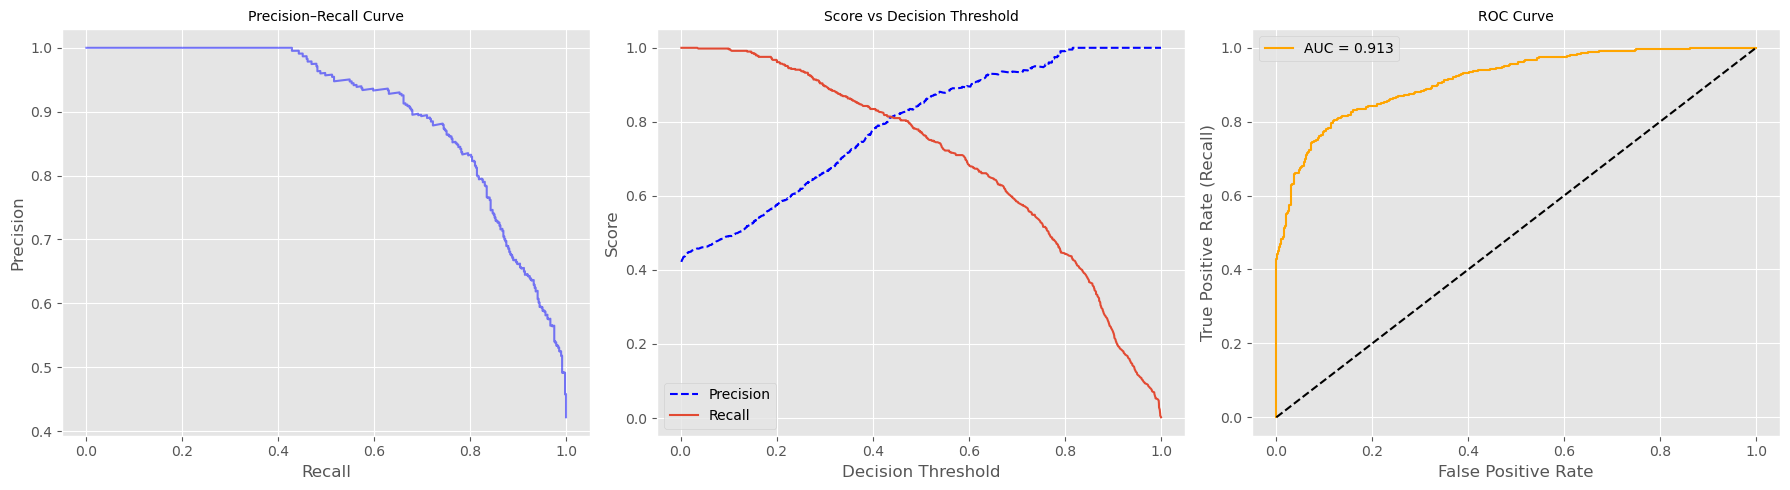

In [19]:
y_score_default = binary_clf.predict_proba(X_val)[:, 0]
y_true_c = (Y_val_type_enc == 0).astype(int)

plot_binary_eval_curves(y_true_c, y_score_default)

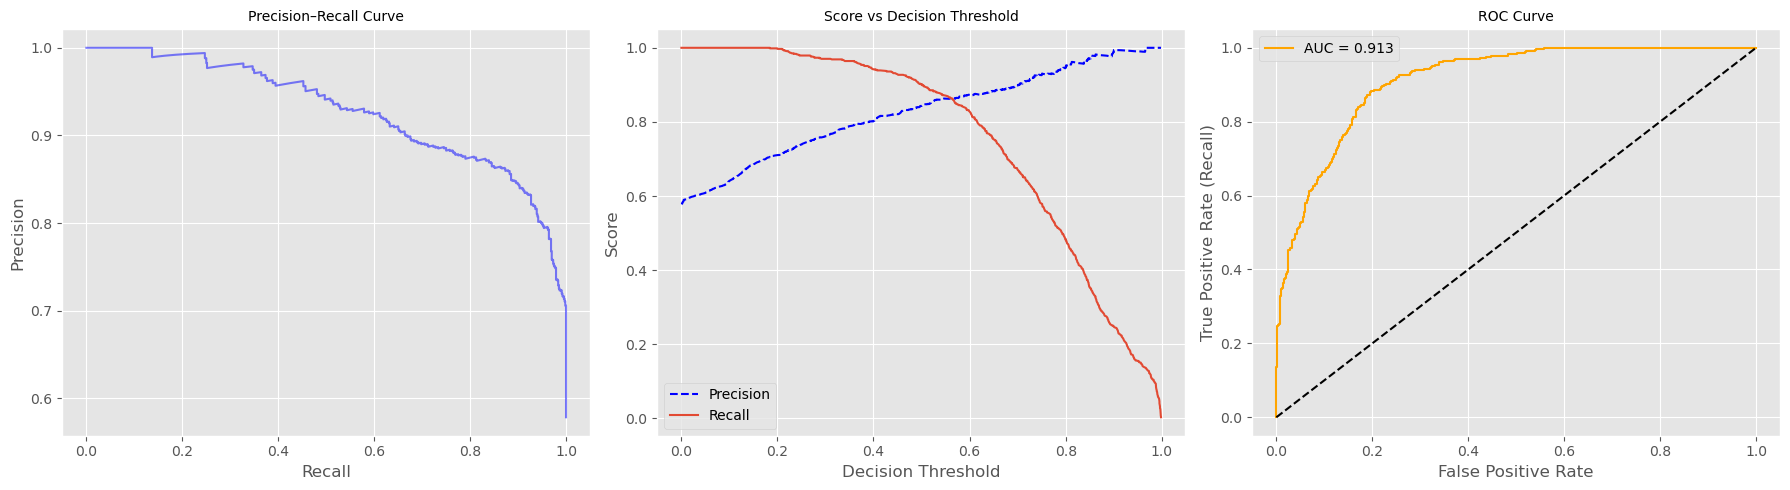

In [50]:
y_score_default = binary_clf.predict_proba(X_val)[:, 1]
y_true_n = (Y_val_type_enc == 1).astype(int)

plot_binary_eval_curves(y_true_n, y_score_default)

* PR curve: high sensitivity means i must accept more false positives
* Score vs threshold: lower thershold increases recall, but decreases precision too
    * critical region threshold~0.3-0.5
    * threshold dominates performance
* ROC curve: classifier is strong; classifier is able to separate C vs N across all thresholds
    * above i have plotted for Carbon as positive; this means that if a random sample is picked there is a 91,3% chance that Carbon gets a higher score

In [20]:
Y_pred_val_df = binary_clf.predict(X_val)
print(classification_report(Y_val_type_enc, Y_pred_val_df, target_names=le_type.classes_))

              precision    recall  f1-score   support

      carbon       0.85      0.77      0.81       490
    nitrogen       0.84      0.90      0.87       672

    accuracy                           0.85      1162
   macro avg       0.85      0.84      0.84      1162
weighted avg       0.85      0.85      0.85      1162



In [133]:
binary_pred_val_def, source_pred_val_def, uptake_pred_val_def = make_prediction3(binary_clf, X_val, threshold=0.5)

In [135]:
print(classification_report(Y_val_c_enc, carbon_clf.predict(X_val_c), target_names=le_carbon.classes_))

              precision    recall  f1-score   support

          ac       0.91      0.87      0.89        77
         glc       0.82      0.81      0.82       112
        glyc       0.81      0.54      0.65        93
        lcts       0.66      0.91      0.77       126
        succ       0.97      0.82      0.89        82

    accuracy                           0.80       490
   macro avg       0.83      0.79      0.80       490
weighted avg       0.82      0.80      0.79       490



In [139]:
carbon_idx = (binary_pred_val_def == carbon_label)

carbon_pred = source_pred_val_def[carbon_idx]
carbon_true = Y_val_source[carbon_idx]

print(classification_report(Y_val_source[carbon_idx], source_pred_val_def[carbon_idx], labels=le_carbon.classes_))

              precision    recall  f1-score   support

          ac       0.59      0.62      0.60        21
         glc       0.69      0.81      0.75        96
        glyc       0.67      0.52      0.58        77
        lcts       0.57      0.94      0.71       115
        succ       0.92      0.81      0.86        69

   micro avg       0.66      0.78      0.72       378
   macro avg       0.69      0.74      0.70       378
weighted avg       0.69      0.78      0.72       378



In [141]:
print(classification_report(Y_val_n_enc, nitrogen_clf.predict(X_val_n), target_names=le_nitrogen.classes_))

              precision    recall  f1-score   support

         arg       0.78      0.96      0.86       305
         nh4       0.87      0.79      0.83       156
         no3       0.90      0.66      0.76       211

    accuracy                           0.83       672
   macro avg       0.85      0.81      0.82       672
weighted avg       0.84      0.83      0.82       672



In [143]:
nitrogen_idx = (binary_pred_val_def == nitrogen_label)

nitrogen_pred = source_pred_val_def[nitrogen_idx]
nitrogen_true = Y_val_source[nitrogen_idx]

print(classification_report(Y_val_source[nitrogen_idx], source_pred_val_def[nitrogen_idx], labels=le_nitrogen.classes_))

              precision    recall  f1-score   support

         arg       0.67      0.96      0.79       269
         nh4       0.74      0.80      0.77       132
         no3       0.74      0.68      0.71       205

   micro avg       0.70      0.83      0.76       606
   macro avg       0.72      0.81      0.76       606
weighted avg       0.71      0.83      0.76       606



***

In [60]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

grid_search = GridSearchCV(
    estimator=binary_clf,
    param_grid=param_grid,
    cv=skf,
    n_jobs=-1,
    verbose=1,
)

PRØV Å FÅ DETTE IGJEN, OG BARE BEHOLD DET. GÅ VIDERE OG TUNE NESTE CLASSIFIER, OG SÅ ER DET OVER
```text
Best params: {'class_weight': None, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Train score: 0.9834194659776055 
Val score: 0.9302925989672978

In [61]:
grid_search.fit(X_train, Y_train_type_enc)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time f

In [62]:
best_binary_clf = grid_search.best_estimator_

print("Best params:", grid_search.best_params_)

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [63]:
# best_binary_clf = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=20,
#     min_samples_split=2,
#     min_samples_leaf=1,
#     class_weight=None,
#     random_state=42,
#     n_jobs=-1,
# )


model = best_binary_clf
# model.fit(X_train, Y_train_type_enc)
print("Train score:", model.score(X_train, Y_train_type_enc))
print("Val score:", model.score(X_val, Y_val_type_enc))

Train score: 1.0
Val score: 0.8562822719449226


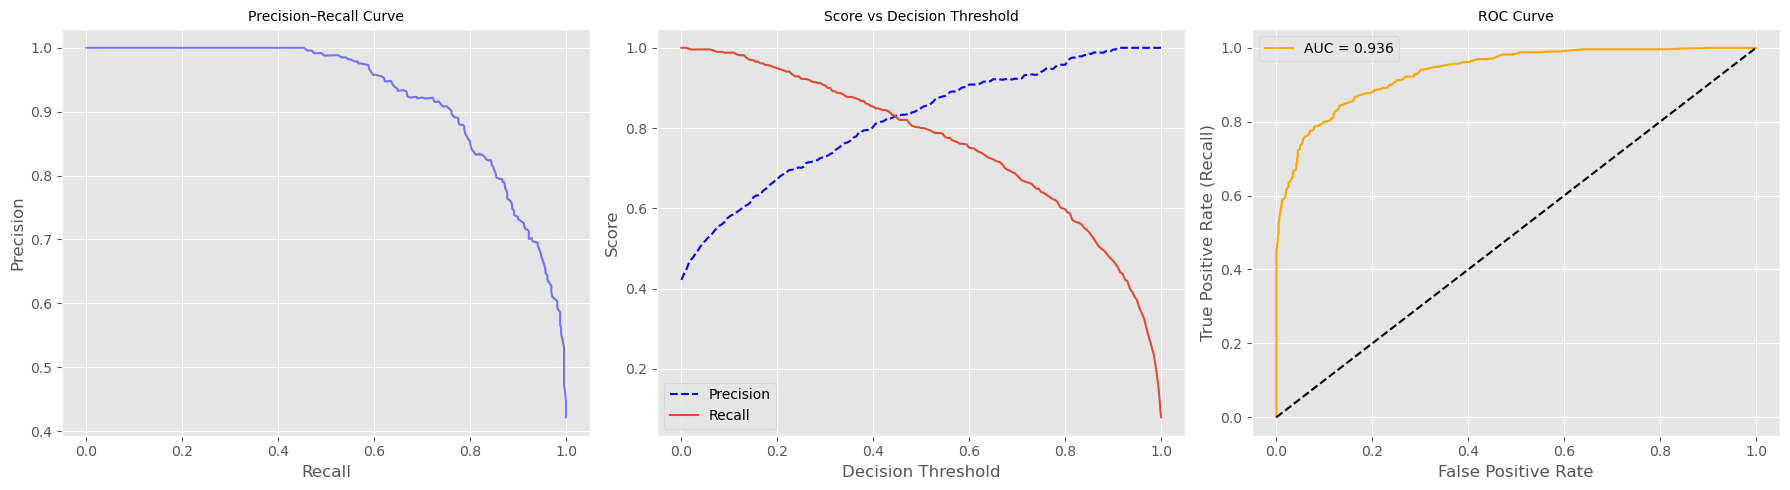

In [64]:
y_score = best_binary_clf.predict_proba(X_val)[:, 0]
y_true_c = (Y_val_type_enc == 0).astype(int)

plot_binary_eval_curves(y_true_c, y_score)

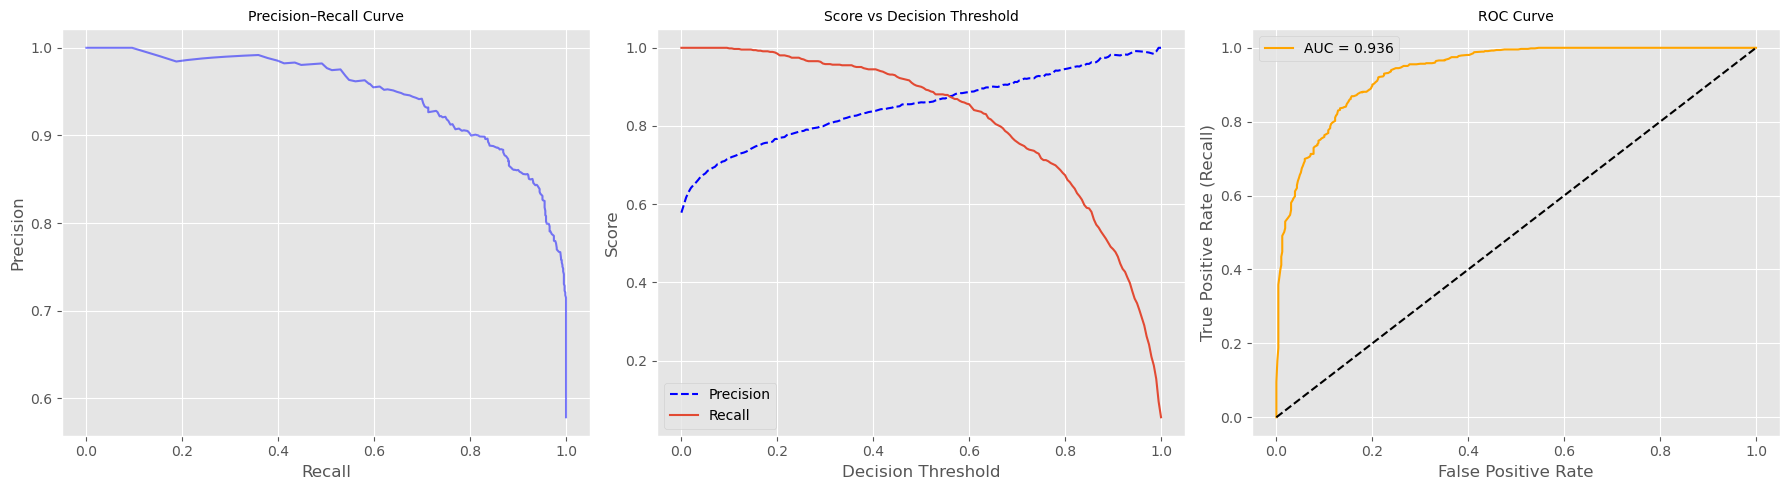

In [65]:
y_score = best_binary_clf.predict_proba(X_val)[:, 1]
y_true_n = (Y_val_type_enc == 1).astype(int)

plot_binary_eval_curves(y_true_n, y_score)

In [66]:
Y_pred_best = best_binary_clf.predict(X_val)
print(classification_report(Y_val_type_enc, Y_pred_best, target_names=le_type.classes_))

              precision    recall  f1-score   support

      carbon       0.85      0.80      0.82       490
    nitrogen       0.86      0.90      0.88       672

    accuracy                           0.86      1162
   macro avg       0.86      0.85      0.85      1162
weighted avg       0.86      0.86      0.86      1162



In [67]:
depths = [estimator.tree_.max_depth for estimator in best_binary_clf.estimators_]

print("Max depth (deepest tree):", max(depths))
print("Average depth:", sum(depths) / len(depths))

Max depth (deepest tree): 33
Average depth: 25.83


* Carbon recall increased, and not at the expence of nitrogen precision or recall
* GridSearch took 7min9s

* results here are a bit different because of fewer source lables for nitrogen sources

### Testing best_binary_clf with different thresholds:

In [210]:
binary_pred_val, source_pred_val, uptake_pred_val = make_prediction3(best_binary_clf, X_val, threshold=0.5)

In [211]:
print(classification_report(Y_val_type_enc, binary_pred_val, target_names=le_type.classes_))

              precision    recall  f1-score   support

      carbon       0.85      0.80      0.82       490
    nitrogen       0.86      0.90      0.88       672

    accuracy                           0.86      1162
   macro avg       0.86      0.85      0.85      1162
weighted avg       0.86      0.86      0.86      1162



In [212]:
carbon_idx = (binary_pred_val == carbon_label)

carbon_pred = source_pred_val[carbon_idx]
carbon_true = Y_val_source[carbon_idx]

print(classification_report(Y_val_source[carbon_idx], source_pred_val[carbon_idx], labels=le_carbon.classes_))

              precision    recall  f1-score   support

          ac       0.49      0.78      0.60        27
         glc       0.70      0.81      0.75       100
        glyc       0.72      0.54      0.62        78
        lcts       0.61      0.96      0.74       116
        succ       0.92      0.82      0.87        71

   micro avg       0.68      0.80      0.73       392
   macro avg       0.69      0.78      0.72       392
weighted avg       0.70      0.80      0.73       392



In [213]:
nitrogen_idx = (binary_pred_val == nitrogen_label)

print(classification_report(Y_val_source[nitrogen_idx], source_pred_val[nitrogen_idx], labels=le_nitrogen.classes_))

              precision    recall  f1-score   support

         arg       0.68      0.96      0.80       277
         nh4       0.76      0.81      0.78       129
         no3       0.77      0.68      0.72       197

   micro avg       0.72      0.84      0.77       603
   macro avg       0.74      0.82      0.77       603
weighted avg       0.73      0.84      0.77       603



* threshold at 0.4-0.45 is good, any less will be too costly for nitrogen sources in stage 2

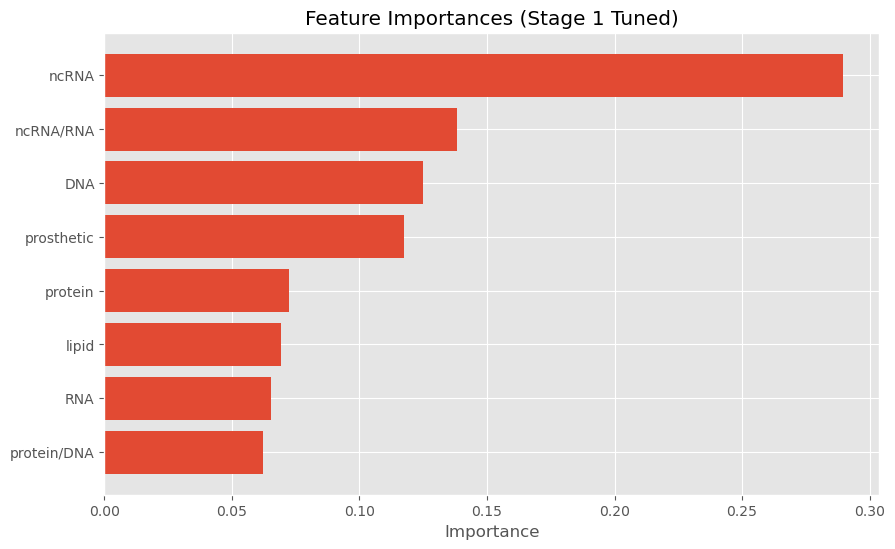

In [165]:
importances = best_binary_clf.feature_importances_

features = X_train.columns.tolist()
feature_names = [col.split('_')[0] for col in features]
# Create DataFrame
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importances (Stage 1 Tuned)")
plt.xlabel("Importance")
plt.show()

In [219]:
for i, col in enumerate(Y_val_num.columns):
    y_true = Y_val_num.iloc[:, i].values
    y_pred = uptake_pred_val[:, i]

    mask = y_true > 0

    if mask.sum() < 2:
        print(f"{col:<20} Not enough positive samples")
        continue

    rmse_val = rmse(y_true[mask], y_pred[mask])
    mae_val = mae(y_true[mask], y_pred[mask])
    r2_val = r2_score(y_true[mask], y_pred[mask])

    print(f"{col:<20} RMSE: {rmse_val:>8.3f}   MAE: {mae_val:>8.3f}   R²:{r2_val:>8.3f}")

EX_o2_e              RMSE:   17.055   MAE:   12.032   R²:   0.718
EX_glc__D_e          RMSE:   11.557   MAE:    8.525   R²:   0.668
EX_ac_e              RMSE:   40.436   MAE:   29.473   R²:  -0.719
EX_lcts_e            RMSE:   43.449   MAE:   26.320   R²:   0.234
EX_glyc_e            RMSE:   41.166   MAE:   23.099   R²:  -0.109
EX_succ_e            RMSE:   24.905   MAE:   14.841   R²:   0.632
EX_arg__L_e          RMSE:   22.266   MAE:   13.966   R²:   0.666
EX_nh4_e             RMSE:   11.255   MAE:    4.589   R²:   0.712
EX_no3_e             RMSE:   14.206   MAE:    8.090   R²:   0.856


* den går faktisk opp for de den sliter aller mest med, dette er i favør for classifiers

```text
EX_o2_e              RMSE:   15.327   MAE:   10.670   R²:   0.772
EX_glc__D_e          RMSE:   10.998   MAE:    7.834   R²:   0.699
EX_ac_e              RMSE:   46.096   MAE:   34.199   R²:  -1.234
EX_lcts_e            RMSE:   45.696   MAE:   26.984   R²:   0.153
EX_glyc_e            RMSE:   41.641   MAE:   22.913   R²:  -0.134
EX_succ_e            RMSE:   24.906   MAE:   13.621   R²:   0.632
EX_arg__L_e          RMSE:   20.740   MAE:   12.599   R²:   0.711
EX_nh4_e             RMSE:   10.802   MAE:    4.563   R²:   0.735
EX_no3_e             RMSE:   10.098   MAE:    6.263   R²:   0.927

## 1.2 - Tuning Stage 2

In [197]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    auc
)


def plot_multiclass_eval_curves(
    y_true,
    y_score,
    class_names=None,
    figsize=(18, 5),
):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    n_classes = y_score.shape[1]
    classes = np.arange(n_classes)

    if class_names is None:
        class_names = [f"class_{i}" for i in classes]

    if len(class_names) != n_classes:
        raise ValueError("class_names must have length equal to y_score.shape[1].")

    # One-vs-rest binarization
    y_onehot = label_binarize(y_true, classes=classes)

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # Define consistent colors per class
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for class_id, class_name in enumerate(class_names):
        color = color_cycle[class_id % len(color_cycle)]

        y_true_bin = y_onehot[:, class_id]
        y_score_bin = y_score[:, class_id]

        if np.unique(y_true_bin).size < 2:
            print(f"Skipping {class_name}: only one class present in y_true.")
            continue

        precision, recall, pr_thresholds = precision_recall_curve(
            y_true_bin, y_score_bin
        )

        fpr, tpr, _ = roc_curve(y_true_bin, y_score_bin)
        roc_auc = auc(fpr, tpr)

        # 1) Precision-Recall curve
        axes[0].plot(
            recall,
            precision,
            color=color,
            label=class_name,
        )

        # 2) SAME color, different linestyle
        axes[1].plot(
            pr_thresholds,
            precision[:-1],
            linestyle="--",
            color=color,
            label=f"{class_name} Precision",
        )
        axes[1].plot(
            pr_thresholds,
            recall[:-1],
            linestyle="-",
            color=color,
            label=f"{class_name} Recall",
        )

        # 3) ROC curve
        axes[2].plot(
            fpr,
            tpr,
            color=color,
            label=f"{class_name} (AUC = {roc_auc:.3f})",
        )

    # Formatting
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")
    axes[0].set_title("Precision–Recall Curve")
    axes[0].legend()

    axes[1].set_xlabel("Decision Threshold")
    axes[1].set_ylabel("Score")
    axes[1].set_title("Score vs Decision Threshold")
    axes[1].legend(fontsize=8, ncol=2)

    axes[2].plot([0, 1], [0, 1], "k--", label="Chance")
    axes[2].set_xlabel("False Positive Rate")
    axes[2].set_ylabel("True Positive Rate")
    axes[2].set_title("ROC Curve")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

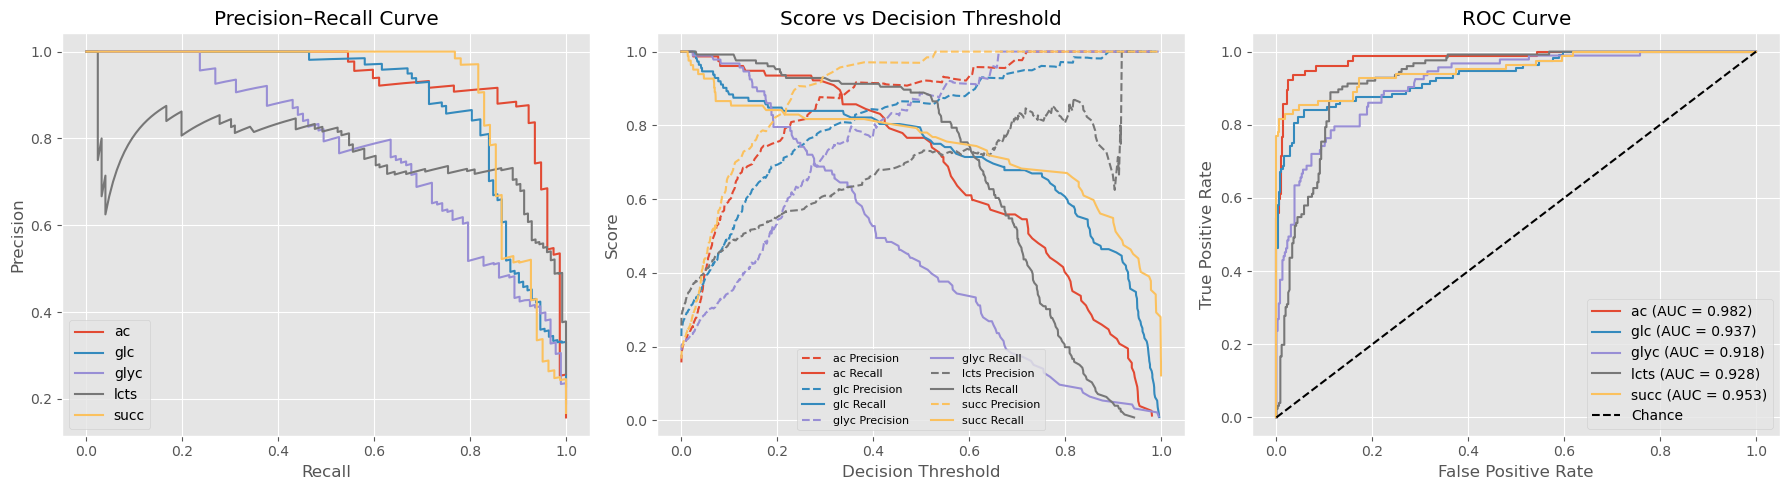

In [201]:
y_score_c = carbon_clf.predict_proba(X_val_c)

plot_multiclass_eval_curves(
    y_true=Y_val_c_enc,
    y_score=y_score_c,
    class_names=list(le_carbon.classes_)
)

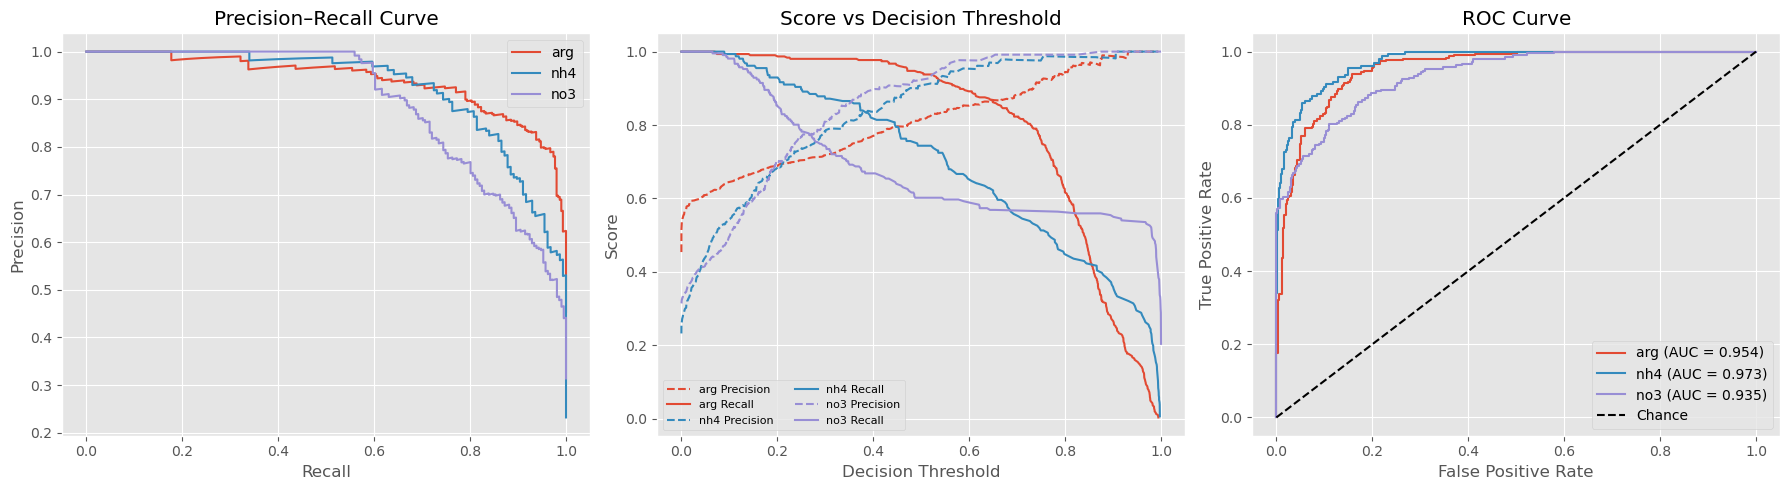

In [200]:
y_score_n = nitrogen_clf.predict_proba(X_val_n)

plot_multiclass_eval_curves(
    y_true=Y_val_n_enc,
    y_score=y_score_n,
    class_names=list(le_nitrogen.classes_)
)

In [168]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_c = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 3],
    'class_weight':[None, "balanced", "balanced_subsample"]
}

grid_search_c = GridSearchCV(
    estimator=carbon_clf,
    param_grid=param_grid_c,
    cv=skf,
    n_jobs=-1,
    verbose=1,
)

In [169]:
param_grid_n = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 3],
    'class_weight':[None, "balanced", "balanced_subsample"]
}

grid_search_n = GridSearchCV(
    estimator=nitrogen_clf,
    param_grid=param_grid_n,
    cv=skf,
    n_jobs=-1,
    verbose=1,
)

In [171]:
grid_search_c.fit(X_train_c, Y_train_c_enc)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced', ...], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.-

* 16min46s

In [172]:
best_carbon_clf = grid_search_c.best_estimator_

print("Best params:", grid_search_c.best_params_)

Best params: {'class_weight': None, 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 200}


In [173]:
grid_search_n.fit(X_train_n, Y_train_n_enc)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced', ...], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.-

In [174]:
best_nitrogen_clf = grid_search_n.best_estimator_

print("Best params:", grid_search_n.best_params_)

Best params: {'class_weight': 'balanced_subsample', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}


In [175]:
depths = [estimator.tree_.max_depth for estimator in best_nitrogen_clf.estimators_]

print("Max depth (deepest tree):", max(depths))
print("Average depth:", sum(depths) / len(depths))

Max depth (deepest tree): 26
Average depth: 19.6


In [177]:
print(classification_report(Y_val_c_enc, best_carbon_clf.predict(X_val_c), target_names=le_carbon.classes_))

              precision    recall  f1-score   support

          ac       0.88      0.78      0.83        77
         glc       0.83      0.80      0.81       112
        glyc       0.75      0.65      0.69        93
        lcts       0.68      0.87      0.77       126
        succ       0.92      0.80      0.86        82

    accuracy                           0.79       490
   macro avg       0.81      0.78      0.79       490
weighted avg       0.80      0.79      0.79       490



In [176]:
print(classification_report(Y_val_n_enc, best_nitrogen_clf.predict(X_val_n), target_names=le_nitrogen.classes_))

              precision    recall  f1-score   support

         arg       0.83      0.94      0.88       305
         nh4       0.86      0.84      0.85       156
         no3       0.90      0.73      0.81       211

    accuracy                           0.85       672
   macro avg       0.86      0.84      0.85       672
weighted avg       0.86      0.85      0.85       672



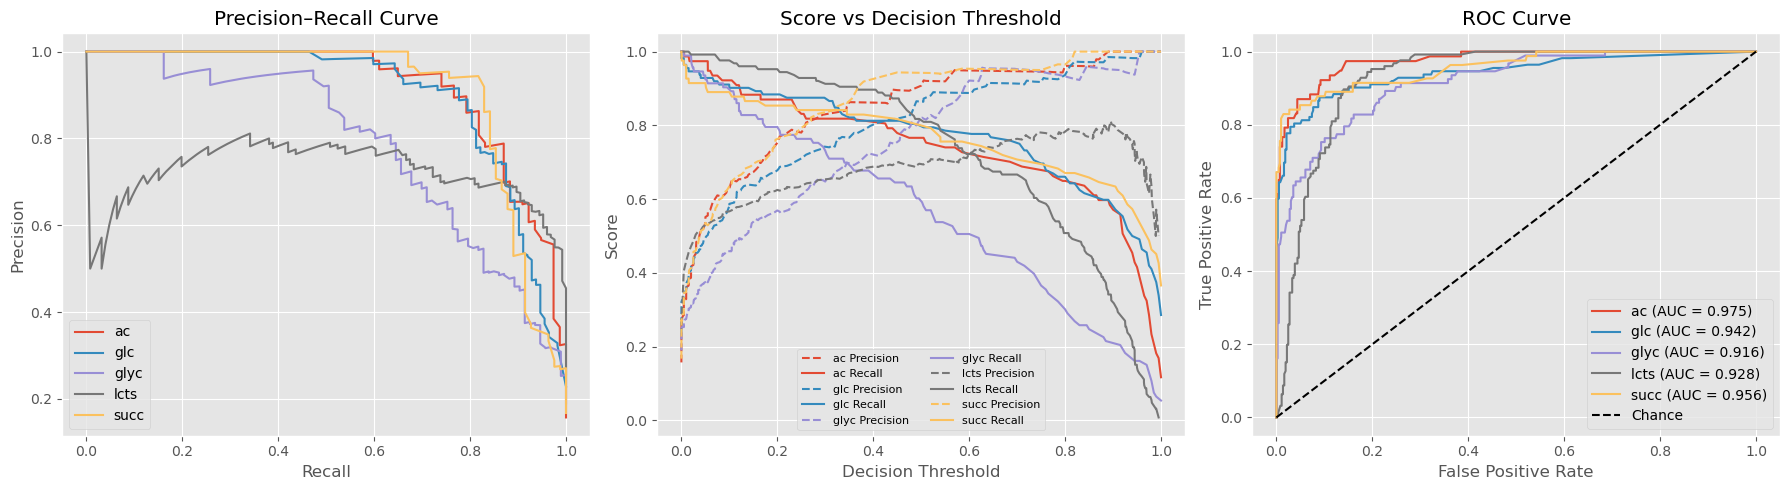

In [199]:
y_score_c = best_carbon_clf.predict_proba(X_val_c)

plot_multiclass_eval_curves(
    y_true=Y_val_c_enc,
    y_score=y_score_c,
    class_names=list(le_carbon.classes_)
)

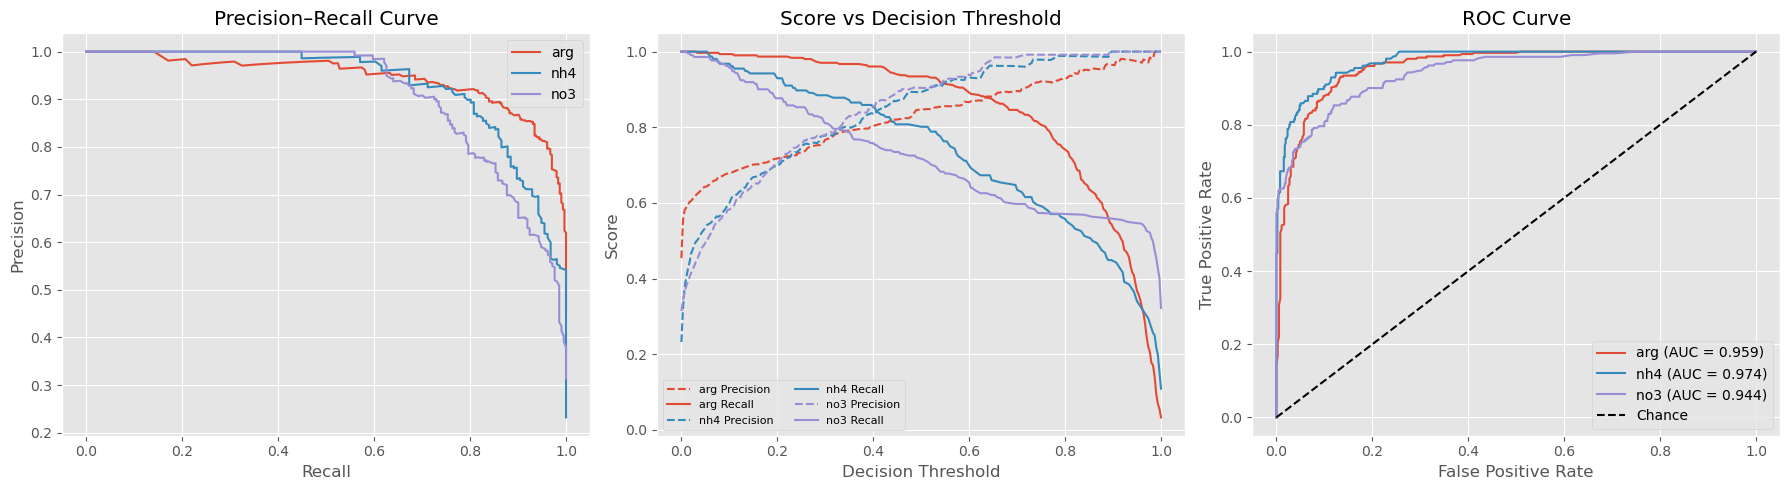

In [198]:
y_score_n = best_nitrogen_clf.predict_proba(X_val_n)

plot_multiclass_eval_curves(
    y_true=Y_val_n_enc,
    y_score=y_score_n,
    class_names=list(le_nitrogen.classes_)
)

# Test

In [242]:
test_data = pd.read_pickle(DATA/"ml_datasets/IID_TEST_raw.pkl")
test_features = pd.read_pickle(DATA/"ml_datasets/L2_FEATURES_TEST.pkl")

In [243]:
test_target = test_data[rxn_cols]
test_target = (-test_target.clip(upper=0))
test_target[test_target == 0] = 0 # to avoid negative

test_target['source'] = test_data['source'].str.split('_').str[0] #less specific nitrogen source
test_target['source_type'] = test_target['source'].str.contains(r'arg|nh4|no3', case=False, na=False).map({True: 'nitrogen', False: 'carbon'})

In [245]:
X_test = test_features.copy()
Y_test = test_target.copy()

In [295]:
# Y_val_type_enc = le_type.transform(Y_val_type)

Y_test_type_enc = le_type.transform(Y_test['source_type'])
Y_test_source = Y_test['source']

c_mask_test = (Y_test['source_type'] == "carbon")
n_mask_test = (Y_test['source_type'] == "nitrogen")


Y_test_c = Y_test_source[c_mask_test]
Y_test_n = Y_test_source[n_mask_test]
X_test_c = X_test[c_mask_test]
X_test_n = X_test[n_mask_test]

Y_test_c_enc = le_carbon.transform(Y_test_c)
Y_test_n_enc = le_nitrogen.transform(Y_test_n)

In [326]:
Y_test_enc = le_source.transform(Y_test['source'])

In [319]:
binary_test, source_test, uptake_test = make_prediction3(binary_clf, X_test, threshold=0.5)

In [320]:
print(classification_report(Y_test_type_enc, binary_test, target_names=le_type.classes_))

              precision    recall  f1-score   support

      carbon       0.71      0.71      0.71       612
    nitrogen       0.79      0.79      0.79       840

    accuracy                           0.76      1452
   macro avg       0.75      0.75      0.75      1452
weighted avg       0.76      0.76      0.76      1452



In [296]:
print(classification_report(Y_test_c_enc, carbon_clf.predict(X_test_c), target_names=le_carbon.classes_))

              precision    recall  f1-score   support

          ac       0.70      0.69      0.69        96
         glc       0.69      0.70      0.69       141
        glyc       0.64      0.59      0.61       116
        lcts       0.61      0.87      0.71       158
        succ       0.63      0.26      0.37       101

    accuracy                           0.65       612
   macro avg       0.65      0.62      0.62       612
weighted avg       0.65      0.65      0.63       612



In [324]:
print(classification_report(Y_test_c_enc, best_carbon_clf.predict(X_test_c), target_names=le_carbon.classes_))

              precision    recall  f1-score   support

          ac       0.71      0.71      0.71        96
         glc       0.73      0.67      0.70       141
        glyc       0.51      0.54      0.53       116
        lcts       0.60      0.80      0.69       158
        succ       0.56      0.29      0.38       101

    accuracy                           0.62       612
   macro avg       0.62      0.60      0.60       612
weighted avg       0.62      0.62      0.61       612



In [290]:
carbon_idx = (binary_test == carbon_label)

print(classification_report(Y_test_source[carbon_idx], source_test[carbon_idx], labels=le_carbon.classes_))

              precision    recall  f1-score   support

          ac       0.27      0.31      0.29        32
         glc       0.49      0.76      0.60       126
        glyc       0.43      0.44      0.43        73
        lcts       0.55      0.89      0.68       142
        succ       0.46      0.31      0.37        83

   micro avg       0.49      0.64      0.55       456
   macro avg       0.44      0.54      0.47       456
weighted avg       0.48      0.64      0.53       456



In [322]:
print(classification_report(Y_test_n_enc, nitrogen_clf.predict(X_test_n), target_names=le_nitrogen.classes_))

              precision    recall  f1-score   support

         arg       0.75      0.93      0.83       381
         nh4       0.79      0.67      0.73       195
         no3       0.93      0.70      0.80       264

    accuracy                           0.80       840
   macro avg       0.82      0.77      0.78       840
weighted avg       0.81      0.80      0.79       840



In [323]:
print(classification_report(Y_test_n_enc, best_nitrogen_clf.predict(X_test_n), target_names=le_nitrogen.classes_))

              precision    recall  f1-score   support

         arg       0.76      0.93      0.83       381
         nh4       0.81      0.69      0.75       195
         no3       0.92      0.72      0.81       264

    accuracy                           0.81       840
   macro avg       0.83      0.78      0.80       840
weighted avg       0.82      0.81      0.80       840



In [291]:
nitrogen_idx = (binary_test == nitrogen_label)

print(classification_report(Y_test_source[nitrogen_idx], source_test[nitrogen_idx], labels=le_nitrogen.classes_))

              precision    recall  f1-score   support

         arg       0.58      0.94      0.72       318
         nh4       0.73      0.63      0.68       142
         no3       0.84      0.76      0.80       244

   micro avg       0.67      0.82      0.74       704
   macro avg       0.72      0.78      0.73       704
weighted avg       0.70      0.82      0.74       704



### Global classifier:

In [ ]:
print(classification_report(Y_test_enc, global_clf.predict(X_test), target_names=le_source.classes_))

              precision    recall  f1-score   support

          ac       0.25      0.01      0.02        96
         arg       0.50      0.87      0.64       381
         glc       0.41      0.67      0.51       141
        glyc       0.58      0.12      0.20       116
        lcts       0.58      0.73      0.64       158
         nh4       0.71      0.40      0.51       195
         no3       0.86      0.69      0.77       264
        succ       0.71      0.12      0.20       101

    accuracy                           0.57      1452
   macro avg       0.58      0.45      0.44      1452
weighted avg       0.60      0.57      0.53      1452



## CMs

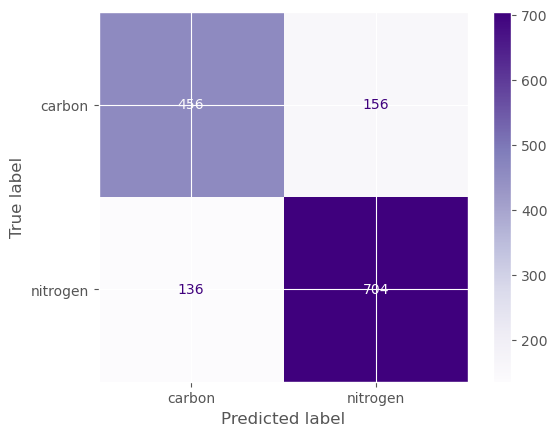

In [332]:
Y_pred_test = best_binary_clf.predict(X_test)

cm = confusion_matrix(Y_test_type_enc, Y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=le_type.classes_)

disp.plot(cmap='Purples')
# plt.title("Primary Sources Only (raw)")
plt.show()

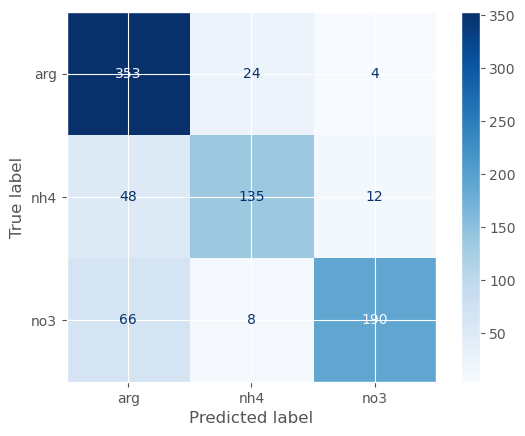

In [330]:
Y_pred_test = best_nitrogen_clf.predict(X_test_n)

cm = confusion_matrix(Y_test_n_enc, Y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=le_nitrogen.classes_)

disp.plot(cmap='Blues')
# plt.title("Primary Sources Only (raw)")
plt.show()

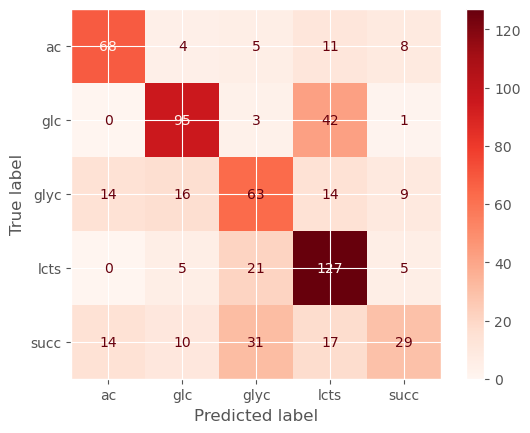

In [331]:
Y_pred_test = best_carbon_clf.predict(X_test_c)

cm = confusion_matrix(Y_test_c_enc, Y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=le_carbon.classes_)

disp.plot(cmap='Reds')
# plt.title("Primary Sources Only (raw)")
plt.show()